### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_10208/767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


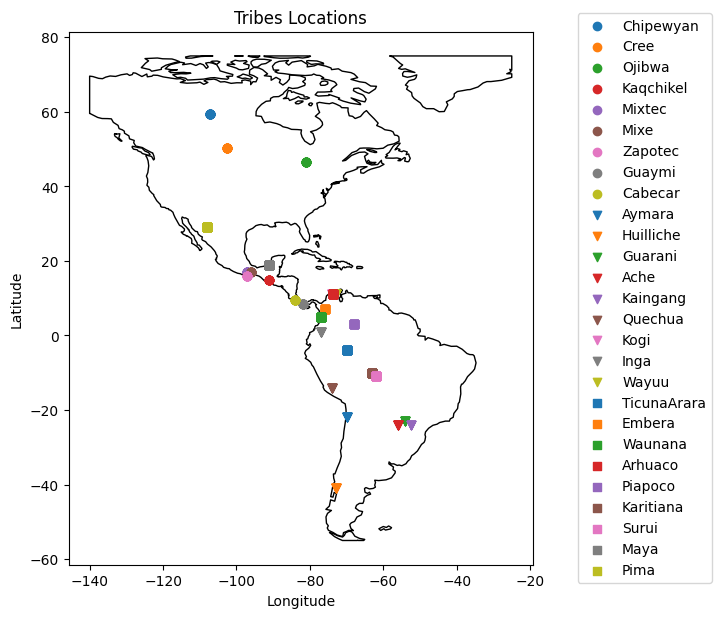

In [8]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [7]:
import numpy as np

# Select only the genetic markers of the df as predictors (X)
X = df.iloc[: , 8:]

# We want to predict the longitude
y = longitude

# Calculate beta hat
XtX = X.T @ X
Xty = X.T @ y
beta_hat = np.linalg.solve(XtX, Xty)

LinAlgError: Singular matrix

**Answer:**

When we try to use `linalg.solve`, we run into a singular matrix error. This is caused by the shape of the dataset. We have indeed $rank(X) \leq N < p$, with $N$ the number of observations *(rows)* and $p$ the number of predictors *(columns)*. This means that $rank(X^TX) \leq N < p$, but the size of the matrix $X^TX$ is $p \times p$. The matrix is therefore non inversible and `linalg.solve` can't fonction properly.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [ ]:
# Calculate beta hat using linalg.lstsq
beta_hat = np.linalg.lstsq(XtX, Xty)
print(beta_hat[0]) # first part of the tuple returned by linalg.lstsq contains the coefficients

[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


**Answer:**

This time we don't have any errors since `linalg.lstsq` is meant to solve the problem we had before. Earlier, we had a lot of null eigenvalues, so the matrix was not inversible. This fonction doesn't try to directly invert the matrix but seeks the minimum norm least squares solution which minimizes $\lVert y - X \beta \rVert_2$. This allows us to have an estimation of the coefficients, even if the matrix is not inversible.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [ ]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
# we print the coefficients
print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


**Answer:**

We can observe that the coefficients are not exactly the same. This is caused by the fact that `sklearn` recenters the predictors before estimating the coefficients. The reason for doing this is that it makes the interpretation of the intercept easier. When we have centered predictors, the origin ordinate $\beta_0$ represents the mean of $y$ (average longitude), which makes the model more readable. It also allows more numerical stability that can be caused by extreme values.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

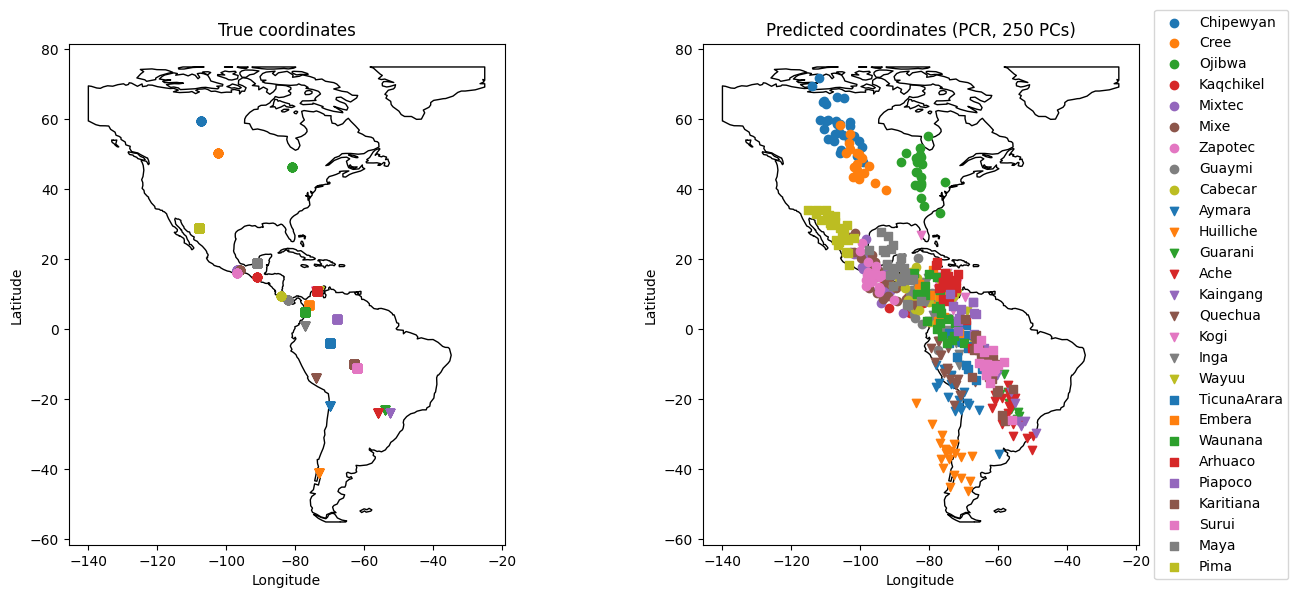

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

y_coords = df[['lat', 'long']].values

# PCA scores using the first 250 components
pca_250 = PCA(n_components=250)
X_scores_250 = pca_250.fit_transform(X)

# Fit linear regression on PCA scores and predict coordinates
lr_pcr_250 = LinearRegression()
lr_pcr_250.fit(X_scores_250, y_coords)
y_pred_coords = lr_pcr_250.predict(X_scores_250)

# Build a dataframe with predicted coordinates for plotting
df_pred = df.copy()
df_pred['lat_pred'] = y_pred_coords[:, 0]
df_pred['long_pred'] = y_pred_coords[:, 1]

# Plot true vs predicted locations (same structure as Exercise 1)
tribe_order = df['Pop'].unique()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, title in zip(axes, ['True coordinates', 'Predicted coordinates (PCR, 250 PCs)']):
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

for i, tribe in enumerate(tribe_order):
    members_true = df[df['Pop'] == tribe]
    members_pred = df_pred[df_pred['Pop'] == tribe]

    axes[0].scatter(
        members_true['long'],
        members_true['lat'],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe
    )
    axes[1].scatter(
        members_pred['long_pred'],
        members_pred['lat_pred'],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe
    )

axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

**Answer:**

The predicted map using 250 principal components globally reproduces the spatial structure seen in the true coordinates: groups remain in geographically coherent areas, with partial separation between tribes. However, because the model is fitted and evaluated on the same individuals, this visualization is **too optimistic** to assess out-of-sample performance.

Without a train/test split (or cross-validation), we mostly measure how well the model reconstructs coordinates of points it has already seen. To estimate the ability to predict the origin of a new individual, the model must be evaluated on data that were not used during training.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

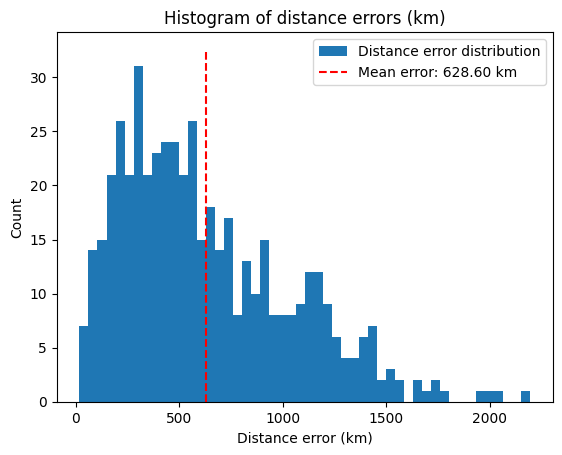

In [40]:
from sklearn.metrics.pairwise import haversine_distances

def calc_dist_err(y_test, y_pred):
    y_test_rad = np.radians(y_test)
    y_pred_rad = np.radians(y_pred)

    distances_km = []
    for i in range(len(y_test_rad)):
        # We calculate the distance between real and predicted
        dist_rad = haversine_distances([y_test_rad[i]], [y_pred_rad[i]])[0][0]
        distances_km.append(dist_rad * 6371)  # multiply by Earth radius to get kilometers

    return distances_km

dist_err = calc_dist_err(y_coords, y_pred_coords)
mean = np.mean(dist_err)
plt.hist(dist_err, bins=50, label="Distance error distribution")
plt.plot([mean, mean], [0, plt.gca().get_ylim()[1]], color='red', linestyle='--', label=f'Mean error: {mean:.2f} km')
plt.title("Histogram of distance errors (km)")
plt.xlabel("Distance error (km)")
plt.ylabel("Count")
plt.legend()
plt.show()

The error of the linear regression model is on average at 628 km, which is quite large. This means that the model is not very accurate in predicting the geographical origin of individuals based on their genetic markers. However, it is important to note that this error is calculated on the same individuals that were used to train the model, so it may be an underestimate of the true error when predicting new individuals.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**Answer :**

The principle of cross-validation is that we divide the training set in $k$ parts (called folds). We then train the model on $k-1$ folds and we test it on the remaining fold. The process is repeated $k$ times so that each observation is used once for the test. This allows a more precise estimation of the performance of the model since we can calculate the average score obtained with the chosen parameters. This is a good way to avoid overfitting. We can then use the best parameters to train the model on the entire training set.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

**Answer :**

The structure of the dataset can cause a problem because the individuals are grouped by tribe (column `Pop`) and by geographical zones. If we do a classical KFold without shuffling the data, there is a risk that we will not have some tribes or geographical areas in the training set, which means that our model will not be able to predict them correctly. The most adequate option is to use `StratifiedkFold` on the `Pop` variable, in order to ensure that there is the same percentage of each tribe in each set.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

# This time we want to predict the complete location so y needs to have both lat and long
X = df[predictors].values
y = df[['lat', 'long']].values

# Function that does the StratifiedKFold (10 splits) and calculates the avg error in km
def eval_PCR(X, y, n):
    # make_pipeline will do : X_train -> StandardScaler -> PCA(4) -> LinearRegression
    pcr_model = make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression())
    
    # We do a stratified 10-KFold as seen in question b)
    kf = StratifiedKFold(n_splits=10)
    test_errors = []
    train_errors = []
    
    for train_index, test_index in kf.split(X, tribes): # we ensure that there is the same % of tribes in each set
        # We do one separation train / test for this iteration
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # We train and predict with the chosen folds
        pcr_model.fit(X_train, y_train)
        y_pred_test = pcr_model.predict(X_test)
        y_pred_train = pcr_model.predict(X_train)
            
        # We calculate the average error (train and test)
        test_errors.append(np.mean(calc_dist_err(y_test, y_pred_test)))
        train_errors.append(np.mean(calc_dist_err(y_train, y_pred_train)))
    
    # Final result
    return np.mean(test_errors), np.mean(train_errors)

# We execute for n=4
cv_error, _ = eval_PCR(X, y, 4)
print(f"Average prediction error (n_components={n}) : {cv_error} km")

/opt/python-ensimag/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


Average prediction error (n_components=212) : 2007.63780962208 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [ ]:
# We ignore the warnings because they are the same as the question before and it will ruin the visibility
import warnings
warnings.filterwarnings('ignore')

n_components = np.arange(2, 440, 100) #TODO : remettre 10 !!

for n in n_components:
    test_err, train_err = eval_PCR(X, y, n)
    # TODO : plot the errors

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.